# EDA — World Happiness Dataset (2015–2019)

Exploratory Data Analysis: missing values, duplicates, schema differences, data types, and outliers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
RAW = "../data/raw"
PROCESSED = "../data/processed"
os.makedirs(PROCESSED, exist_ok=True)


## 1. Load Raw Files

In [2]:
files = {
    2015: f"{RAW}/2015.csv",
    2016: f"{RAW}/2016.csv",
    2017: f"{RAW}/2017.csv",
    2018: f"{RAW}/2018.csv",
    2019: f"{RAW}/2019.csv",
}

dfs = {}
for year, path in files.items():
    dfs[year] = pd.read_csv(path)
    print(f"--- {year} ---  shape={dfs[year].shape}")
    print(f"  columns: {list(dfs[year].columns)}")


--- 2015 ---  shape=(158, 12)
  columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
--- 2016 ---  shape=(157, 13)
  columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
--- 2017 ---  shape=(155, 12)
  columns: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']
--- 2018 ---  shape=(156, 9)
  columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make l

## 2. Schema Differences

In [3]:
for year, df in dfs.items():
    print(f"\n=== {year} ===")
    print(df.dtypes)



=== 2015 ===
Country                              str
Region                               str
Happiness Rank                     int64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

=== 2016 ===
Country                              str
Region                               str
Happiness Rank                     int64
Happiness Score                  float64
Lower Confidence Interval        float64
Upper Confidence Interval        float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity     

## 3. Missing Values

In [4]:
for year, df in dfs.items():
    nulls = df.isnull().sum()
    total = nulls.sum()
    print(f"{year}: {total} missing values total")
    if total > 0:
        print(nulls[nulls > 0])


2015: 0 missing values total
2016: 0 missing values total
2017: 0 missing values total
2018: 1 missing values total
Perceptions of corruption    1
dtype: int64
2019: 0 missing values total


## 4. Duplicate Records

In [5]:
for year, df in dfs.items():
    dupes = df.duplicated().sum()
    print(f"{year}: {dupes} duplicate rows")


2015: 0 duplicate rows
2016: 0 duplicate rows
2017: 0 duplicate rows
2018: 0 duplicate rows
2019: 0 duplicate rows


## 5. Data Quality Observations

| Year | Region | Happiness Col | GDP Col | Family Col | Health Col | Corruption Col |
|------|--------|---------------|---------|------------|------------|----------------|
| 2015 | ✓ | Happiness Score | Economy (GDP per Capita) | Family | Health (Life Expectancy) | Trust (Government Corruption) |
| 2016 | ✓ | Happiness Score | Economy (GDP per Capita) | Family | Health (Life Expectancy) | Trust (Government Corruption) |
| 2017 | ✗ | Happiness.Score | Economy..GDP.per.Capita. | Family | Health..Life.Expectancy. | Trust..Government.Corruption. |
| 2018 | ✗ | Score | GDP per capita | Social support | Healthy life expectancy | Perceptions of corruption |
| 2019 | ✗ | Score | GDP per capita | Social support | Healthy life expectancy | Perceptions of corruption |

**Key observations:**
- Column names are inconsistent across years (dot notation in 2017, different names in 2018/2019)
- `Region` column only exists in 2015 and 2016
- Confidence intervals in 2016 and whisker values in 2017 are year-specific and not useful for ML
- 2018/2019 use 'Social support' instead of 'Family'
- No significant missing values in core feature columns

## 6. Outlier Detection

In [6]:
# Map each year to unified feature names for outlier check
feature_maps = {
    2015: {"happiness_score": "Happiness Score", "gdp": "Economy (GDP per Capita)",
           "family": "Family", "health": "Health (Life Expectancy)",
           "freedom": "Freedom", "generosity": "Generosity",
           "corruption": "Trust (Government Corruption)"},
    2016: {"happiness_score": "Happiness Score", "gdp": "Economy (GDP per Capita)",
           "family": "Family", "health": "Health (Life Expectancy)",
           "freedom": "Freedom", "generosity": "Generosity",
           "corruption": "Trust (Government Corruption)"},
    2017: {"happiness_score": "Happiness.Score", "gdp": "Economy..GDP.per.Capita.",
           "family": "Family", "health": "Health..Life.Expectancy.",
           "freedom": "Freedom", "generosity": "Generosity",
           "corruption": "Trust..Government.Corruption."},
    2018: {"happiness_score": "Score", "gdp": "GDP per capita",
           "family": "Social support", "health": "Healthy life expectancy",
           "freedom": "Freedom to make life choices", "generosity": "Generosity",
           "corruption": "Perceptions of corruption"},
    2019: {"happiness_score": "Score", "gdp": "GDP per capita",
           "family": "Social support", "health": "Healthy life expectancy",
           "freedom": "Freedom to make life choices", "generosity": "Generosity",
           "corruption": "Perceptions of corruption"},
}

features = ["happiness_score", "gdp", "family", "health", "freedom", "generosity", "corruption"]

frames = []
for year, df in dfs.items():
    mapping = feature_maps[year]
    subset = df[[v for v in mapping.values()]].rename(columns={v: k for k, v in mapping.items()})
    subset["year"] = year
    # country column
    if "Country" in df.columns:
        subset["country"] = df["Country"].values
    else:
        subset["country"] = df["Country or region"].values
    frames.append(subset)

unified_raw = pd.concat(frames, ignore_index=True)
print("Unified raw shape:", unified_raw.shape)
unified_raw[features].describe()


Unified raw shape: (782, 9)


,happiness_score,gdp,family,health,freedom,generosity,corruption
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,781.000000
mean,5.379018,0.916047,1.078392,0.612416,0.411091,0.218576,0.125436
std,1.127456,0.407340,0.329548,0.248309,0.152880,0.122321,0.105816
min,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.509750,0.606500,0.869363,0.440183,0.309768,0.130000,0.054000
50%,5.322000,0.982205,1.124735,0.647310,0.431000,0.201982,0.091000
75%,6.189500,1.236187,1.327250,0.808000,0.531000,0.278832,0.156030
max,7.769000,2.096000,1.644000,1.141000,0.724000,0.838075,0.551910


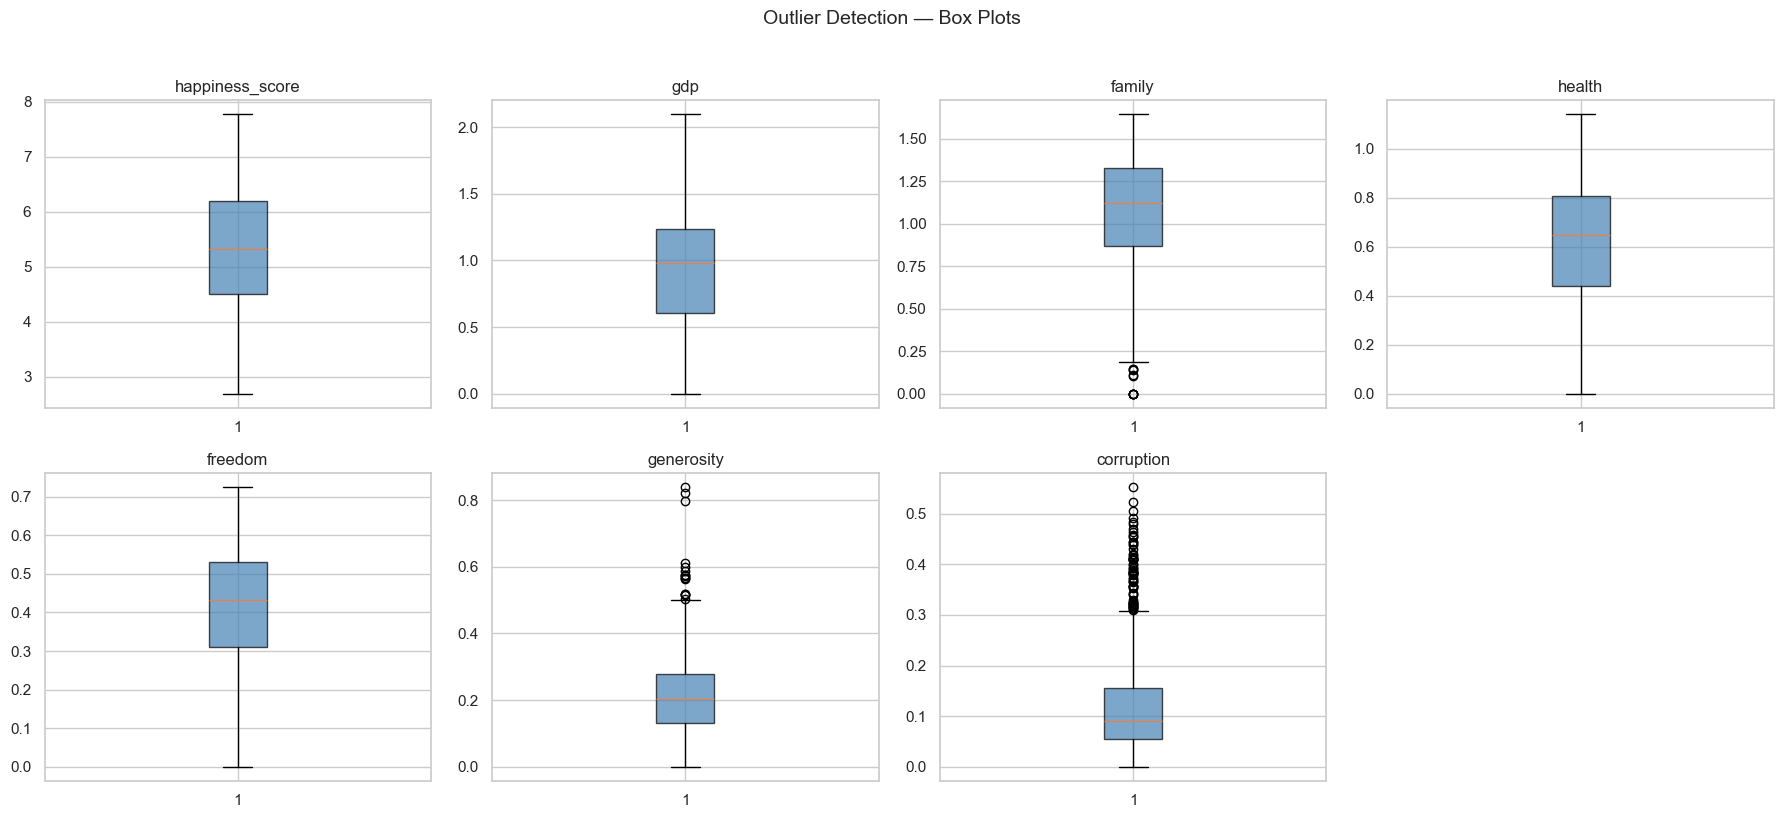

Boxplot saved.


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(features):
    axes[i].boxplot(unified_raw[feat].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(feat)
axes[-1].set_visible(False)
plt.suptitle("Outlier Detection — Box Plots", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{PROCESSED}/outliers_boxplot.png", dpi=100, bbox_inches='tight')
plt.show()
print("Boxplot saved.")


## 7. Correlation Analysis

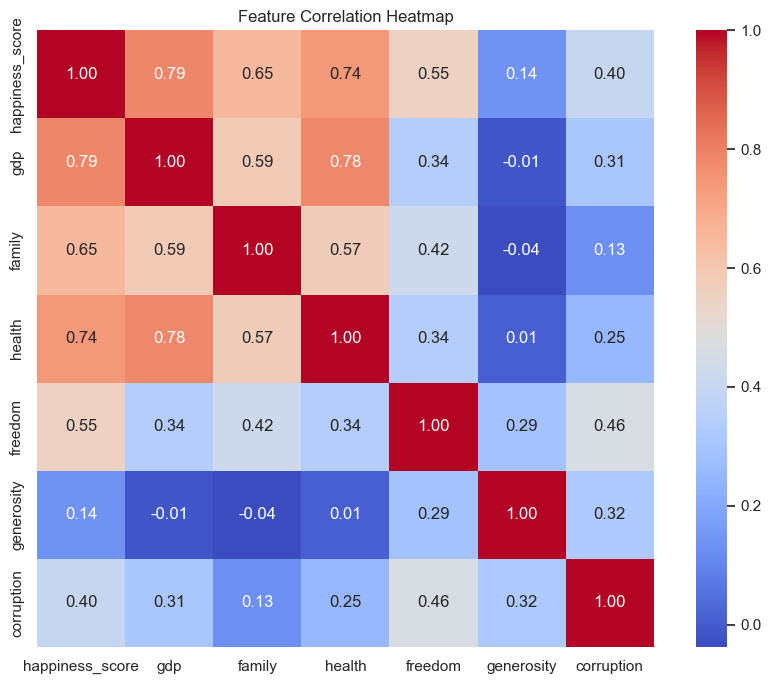

In [8]:
corr = unified_raw[features].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{PROCESSED}/correlation_heatmap.png", dpi=100, bbox_inches='tight')
plt.show()


## 8. Unified Schema Proposal

Based on the EDA, the unified schema is:

```
country           string  — country name
year              int     — report year
happiness_score   float   — target variable
gdp               float   — economy/GDP per capita
family            float   — family/social support
health            float   — health/life expectancy
freedom           float   — freedom indicator
generosity        float   — generosity
corruption        float   — corruption perception
region            string  — region (NaN for 2017–2019)
```

**Cleaning decisions:**
- Drop Dystopia Residual, Standard Error, Confidence Intervals, Whisker columns (non-predictive or year-specific)
- Rename all columns to a canonical snake_case schema
- Fill missing `region` with `'Unknown'` for 2017–2019
- Drop rows where `happiness_score` is NaN (target cannot be missing)
- Rows with missing features will be filled with the year-level median

In [9]:
print("EDA complete. Proceed to data/processed/ for cleaned data.")
print("Unified raw shape:", unified_raw.shape)
print("\nSample:")
print(unified_raw.head())


EDA complete. Proceed to data/processed/ for cleaned data.
Unified raw shape: (782, 9)

Sample:
   happiness_score      gdp   family   health  freedom  generosity  \
0            7.587  1.39651  1.34951  0.94143  0.66557     0.29678   
1            7.561  1.30232  1.40223  0.94784  0.62877     0.43630   
2            7.527  1.32548  1.36058  0.87464  0.64938     0.34139   
3            7.522  1.45900  1.33095  0.88521  0.66973     0.34699   
4            7.427  1.32629  1.32261  0.90563  0.63297     0.45811   

   corruption  year      country  
0     0.41978  2015  Switzerland  
1     0.14145  2015      Iceland  
2     0.48357  2015      Denmark  
3     0.36503  2015       Norway  
4     0.32957  2015       Canada  
